# DA-02. Exact Preservation — Amount 원값 보존 검증

## 분석 목적

Ethereum 거래의 Amount가 데이터 처리 과정에서 변형되지 않고 정확하게 보존되는지 검증한다.

Ethereum Master Sample 73,410건의 `transaction_hash`를 추적 기준으로 사용하고,
동일 거래의 원본 `value`를 Ethereum BigQuery에서 다시 조회하여 Exact Ground Truth를 확보한다.

Master Sample CSV의 기존 `value` 값은 로딩 과정에서 FLOAT64로 해석될 경우
이미 wei 단위 정밀도 손실이 발생할 수 있으므로 Exact Ground Truth로 사용하지 않는다.

따라서 본 분석에서는 동일한 BigQuery 원본 Amount를 기준으로

- Exact Integer / Decimal 기반 처리
- FLOAT64 기반 처리

를 각각 수행한 뒤 다시 wei로 복원하여 원본과 비교한다.

## 전처리 원칙

1. Ethereum Master Sample 73,410건의 `transaction_hash`를 기준 집합으로 사용한다.
2. 동일 hash를 Ethereum BigQuery 원본 거래와 매칭한다.
3. BigQuery `value`는 STRING 형태로 먼저 확보하여 정수 원값을 보존한다.
4. 동일 원본에서 Exact 경로와 FLOAT64 경로를 각각 생성한다.
5. BigQuery와 매칭되지 않은 거래가 존재할 경우 임의 제거하지 않고 별도로 집계한다.
6. 분석 모집단은 원본 Amount가 정상적으로 재확보된 거래 전체로 한다.

## 검증 질문

1. FLOAT64 변환 과정에서 Ethereum Amount의 wei 원값 손실이 실제로 발생하는가?
2. 전체 거래 중 Precision Loss가 발생하는 비율은 어느 정도인가?
3. Amount 규모가 커질수록 FLOAT64 정밀도 손실 가능성이 증가하는가?
4. Exact Integer / Decimal 기반 처리는 원본 wei를 정확하게 보존하는가?

## 가설

### 가설 1 — Exact Preservation

- H0: Exact Integer / Decimal 처리 후 복원된 wei는 원본 wei와 다르다.
- H1: Exact Integer / Decimal 처리 후 복원된 wei는 원본 wei와 동일하다.

### 가설 2 — FLOAT64 Precision Loss

- H0: FLOAT64 변환에서도 원본 wei가 모두 정확하게 보존된다.
- H1: FLOAT64 변환에서는 일부 거래의 원본 wei가 정확하게 보존되지 않는다.

### 가설 3 — Amount 규모와 Precision Loss

- H0: Amount 규모와 FLOAT64 정밀도 손실 발생 가능성은 관련이 없다.
- H1: Amount 규모가 증가할수록 FLOAT64 정밀도 손실 발생 가능성이 증가한다.

## 데이터

### 기준 표본
- Ethereum Master Sample: 73,410건
- 추적 Key: `transaction_hash`

### Exact Ground Truth
- `bigquery-public-data.crypto_ethereum.transactions`
- 동일 `transaction_hash`의 원본 `value`
- `CAST(value AS STRING)`으로 조회하여 wei 정수 원값을 보존

## 주요 검증 지표

- BigQuery 원본 매칭률
- Exact Preservation 성공률
- FLOAT64 Precision Loss 발생 건수
- FLOAT64 Precision Loss 발생률
- 절대 오차(wei)
- 최대 절대 오차(wei)
- Amount 규모별 손실률
- Amount 규모와 손실 발생 여부의 Logistic Regression
- Odds Ratio 및 95% 신뢰구간

## FPG 설계 연결

분석 결과를 기반으로 Digital Asset Amount를 FLOAT64와 같은 부동소수점 자료형으로 처리할 수 있는지 검증하고,
FPG Runtime에서 Amount의 Exact Preservation을 보장하기 위한 자료형 및 Validation Contract를 설계한다.

In [26]:
# 02. 73,410건 원본 Amount 한 번에 조회

import pandas as pd
from google.cloud import bigquery

client = bigquery.Client()

hashes = (
    df_master["transaction_hash"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

# Master Sample 날짜 범위 자동 추출
df_master["block_timestamp"] = pd.to_datetime(
    df_master["block_timestamp"],
    errors="coerce",
    utc=True
)

start_date = df_master["block_timestamp"].min().date()
end_date = df_master["block_timestamp"].max().date()

print("조회 대상 hash:", len(hashes))
print("조회 날짜:", start_date, "~", end_date)

query = """
SELECT
    `hash` AS transaction_hash,
    CAST(value AS STRING) AS value_wei_exact
FROM `bigquery-public-data.crypto_ethereum.transactions`
WHERE DATE(block_timestamp) BETWEEN @start_date AND @end_date
  AND `hash` IN UNNEST(@hashes)
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ScalarQueryParameter(
            "start_date", "DATE", start_date
        ),
        bigquery.ScalarQueryParameter(
            "end_date", "DATE", end_date
        ),
        bigquery.ArrayQueryParameter(
            "hashes", "STRING", hashes
        )
    ]
)

# 먼저 예상 스캔량 확인
dry_config = bigquery.QueryJobConfig(
    dry_run=True,
    use_query_cache=False,
    query_parameters=job_config.query_parameters
)

dry_job = client.query(query, job_config=dry_config)

print(
    "예상 스캔량:",
    f"{dry_job.total_bytes_processed / 1024**3:.4f} GB"
)

# 실제 조회
df_chain = client.query(
    query,
    job_config=job_config
).to_dataframe()

print("BigQuery 매칭:", len(df_chain))

df_exact = df_master.merge(
    df_chain,
    on="transaction_hash",
    how="left",
    validate="one_to_one"
)

matched = df_exact["value_wei_exact"].notna().sum()

print("Master Sample:", len(df_exact))
print("원본 Amount 매칭:", matched)
print("미매칭:", len(df_exact) - matched)
print(f"매칭률: {matched / len(df_exact) * 100:.4f}%")

조회 대상 hash: 73410
조회 날짜: 2025-06-01 ~ 2026-09-07
예상 스캔량: 76.4766 GB
BigQuery 매칭: 73266
Master Sample: 73410
원본 Amount 매칭: 73266
미매칭: 144
매칭률: 99.8038%


In [28]:
# 03. 73,266건 Exact Preservation / FLOAT64 Precision Loss 검증

from decimal import Decimal
import numpy as np

df_exact = df_exact[
    df_exact["value_wei_exact"].notna()
].copy()

# BigQuery STRING 원본 → 정확한 정수 Ground Truth
df_exact["value_wei_exact_int"] = (
    df_exact["value_wei_exact"]
    .map(int)
)

# Exact Decimal 경로
df_exact["value_eth_decimal"] = (
    df_exact["value_wei_exact_int"]
    .map(lambda x: Decimal(x) / Decimal(10**18))
)

df_exact["value_wei_decimal_restored"] = (
    df_exact["value_eth_decimal"]
    .map(lambda x: int(x * Decimal(10**18)))
)

# FLOAT64 경로
df_exact["value_wei_float_restored"] = (
    df_exact["value_wei_exact"]
    .map(lambda x: int(np.float64(x)))
)

# 오차 계산
df_exact["decimal_error_wei"] = (
    df_exact["value_wei_decimal_restored"]
    - df_exact["value_wei_exact_int"]
)

df_exact["float_error_wei"] = (
    df_exact["value_wei_float_restored"]
    - df_exact["value_wei_exact_int"]
)

df_exact["decimal_preserved"] = (
    df_exact["decimal_error_wei"] == 0
)

df_exact["float_preserved"] = (
    df_exact["float_error_wei"] == 0
)

print("분석 거래:", len(df_exact))

print()
print("[Decimal]")

분석 거래: 73266

[Decimal]


In [29]:
# 03. Exact Preservation / FLOAT64 Precision Loss 재검증

from decimal import Decimal
import numpy as np

exact_values = [
    int(x)
    for x in df_exact["value_wei_exact"]
]

# Decimal 왕복
decimal_restored = [
    int(
        (Decimal(x) / Decimal(10**18))
        * Decimal(10**18)
    )
    for x in exact_values
]

decimal_errors = [
    restored - original
    for restored, original in zip(decimal_restored, exact_values)
]

# FLOAT64 왕복
float_restored = [
    int(float(x))
    for x in exact_values
]

float_errors = [
    restored - original
    for restored, original in zip(float_restored, exact_values)
]

decimal_loss = sum(err != 0 for err in decimal_errors)
float_loss = sum(err != 0 for err in float_errors)

print("분석 거래:", len(exact_values))

print("\n[Decimal]")
print("정확 보존:", len(exact_values) - decimal_loss)
print("정밀도 손실:", decimal_loss)
print(
    "보존률:",
    f"{(1 - decimal_loss / len(exact_values)) * 100:.4f}%"
)

print("\n[FLOAT64]")
print("정확 보존:", len(exact_values) - float_loss)
print("정밀도 손실:", float_loss)
print(
    "정밀도 손실률:",
    f"{float_loss / len(exact_values) * 100:.4f}%"
)
print(
    "최대 절대오차(wei):",
    max(abs(x) for x in float_errors)
)

# 이후 분석용 컬럼 저장
df_exact["decimal_error_wei"] = decimal_errors
df_exact["float_error_wei"] = float_errors
df_exact["decimal_preserved"] = np.array(decimal_errors) == 0
df_exact["float_preserved"] = np.array(float_errors) == 0

분석 거래: 73266

[Decimal]
정확 보존: 73266
정밀도 손실: 0
보존률: 100.0000%

[FLOAT64]
정확 보존: 69986
정밀도 손실: 3280
정밀도 손실률: 4.4768%
최대 절대오차(wei): 351232


## 1. Exact Preservation 검증 결과

Ethereum Master Sample 73,410건 중 BigQuery 원본 Amount와 매칭된 **73,266건(99.8038%)**을 대상으로 원값 보존 여부를 검증하였다.

### Decimal 기반 처리

* 정확 보존: **73,266건**
* 정밀도 손실: **0건**
* Exact Preservation Rate: **100.0000%**

Decimal 기반 처리에서는 모든 거래의 원본 wei가 정확하게 복원되었다.

### FLOAT64 기반 처리

* 정확 보존: **69,986건**
* 정밀도 손실: **3,280건**
* Precision Loss Rate: **4.4768%**
* 최대 절대오차: **351,232 wei**

동일한 원본 Amount를 FLOAT64로 변환한 경우 전체 73,266건 중 3,280건에서 원본 wei와 다른 값이 복원되었다.

따라서 Digital Asset Amount를 FLOAT64로 처리할 경우 실제 거래 금액의 원값 보존이 보장되지 않으며, Exact Integer 또는 Decimal 기반 처리가 필요함을 확인하였다.

다만 `value = 0`인 거래는 FLOAT64에서도 필연적으로 정확히 보존되므로, 전체 손실률만으로 Amount 규모와 정밀도 손실의 관계를 판단할 경우 결과가 희석될 수 있다.

따라서 다음 단계에서는 **0 Amount와 실제 Amount가 존재하는 거래를 분리한 뒤**, 양수 Amount 거래를 대상으로 금액 규모별 Precision Loss를 검증한다.


In [30]:
# 04. Zero Amount와 Positive Amount 분리

df_exact["is_zero_amount"] = (
    df_exact["value_wei_exact_int"] == 0
)

amount_status = (
    df_exact
    .groupby("is_zero_amount")
    .agg(
        transactions=("transaction_hash", "count"),
        precision_loss=("float_preserved", lambda x: (~x).sum()),
        loss_rate=("float_preserved", lambda x: (~x).mean() * 100)
    )
)

display(amount_status)

print("전체 거래:", len(df_exact))
print("Zero Amount:", df_exact["is_zero_amount"].sum())
print("Positive Amount:", (~df_exact["is_zero_amount"]).sum())

,transactions,precision_loss,loss_rate
is_zero_amount,,,
False,28953,3280,11.32870514
True,44313,0,0.00000000


전체 거래: 73266
Zero Amount: 44313
Positive Amount: 28953


## 2. Zero Amount와 Positive Amount 분리

전체 73,266건 중 **44,313건은 Amount가 0**이었으며, 해당 거래에서는 FLOAT64 정밀도 손실이 발생하지 않았다.

반면 실제 Amount가 존재하는 **28,953건**에서는 **3,280건의 정밀도 손실**이 발생하여 Precision Loss Rate가 **11.3287%**로 나타났다.

따라서 전체 거래 기준 손실률 4.4768%는 Zero Amount 거래가 다수 포함되면서 희석된 결과이다.

Amount 규모와 Precision Loss의 관계를 검증하기 위해 이후 분석에서는 **Positive Amount 28,953건만을 대상으로 금액 규모를 Q1~Q4로 구분**한다.


In [31]:
# 05. Positive Amount 규모별 Precision Loss 검증

df_positive = df_exact[
    df_exact["value_wei_exact_int"] > 0
].copy()

df_positive["amount_group"] = pd.qcut(
    df_positive["value_wei_exact_int"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    duplicates="drop"
)

amount_summary = (
    df_positive
    .groupby("amount_group", observed=True)
    .agg(
        transactions=("transaction_hash", "count"),
        precision_loss=("float_preserved", lambda x: (~x).sum()),
        loss_rate=("float_preserved", lambda x: (~x).mean() * 100),
        median_abs_error_wei=("float_error_wei", lambda x: x.abs().median()),
        max_abs_error_wei=("float_error_wei", lambda x: x.abs().max())
    )
)

display(amount_summary)

,transactions,precision_loss,loss_rate,median_abs_error_wei,max_abs_error_wei
amount_group,,,,,
Q1,7240,0,0.00000000,0.00000000,0
Q2,7237,0,0.00000000,0.00000000,0
Q3,7237,797,11.01285063,0.00000000,4
Q4,7238,2482,34.29124067,0.00000000,226467


In [32]:
# 06. FLOAT64 안전 정수 경계 기준 Precision Loss 검증

FLOAT64_SAFE_INTEGER = 2**53

df_positive["above_float64_safe_limit"] = (
    df_positive["value_wei_exact_int"] > FLOAT64_SAFE_INTEGER
)

threshold_summary = (
    df_positive
    .groupby("above_float64_safe_limit")
    .agg(
        transactions=("transaction_hash", "count"),
        precision_loss=("float_preserved", lambda x: (~x).sum()),
        loss_rate=("float_preserved", lambda x: (~x).mean() * 100),
        max_abs_error_wei=("float_error_wei", lambda x: x.abs().max())
    )
)

display(threshold_summary)

print("FLOAT64 Safe Integer:", FLOAT64_SAFE_INTEGER)

,transactions,precision_loss,loss_rate,max_abs_error_wei
above_float64_safe_limit,,,,
False,16784,0,0.00000000,0
True,12169,3280,26.95373490,351232


FLOAT64 Safe Integer: 9007199254740992


## 3. FLOAT64 안전 정수 경계 검증

FLOAT64가 정수를 정확하게 표현할 수 있는 안전 경계인 **2^53 = 9,007,199,254,740,992 wei**를 기준으로 Positive Amount 거래를 구분하였다.

* 안전 경계 이하: **16,784건**

  * Precision Loss: **0건**
  * 손실률: **0.0000%**

* 안전 경계 초과: **12,169건**

  * Precision Loss: **3,280건**
  * 손실률: **26.9537%**
  * 최대 절대오차: **351,232 wei**

안전 경계 이하에서는 원값 손실이 한 건도 발생하지 않은 반면, 경계를 초과한 거래에서는 약 **26.95%**에서 원본 wei와 다른 값이 복원되었다.

따라서 FLOAT64 Precision Loss는 단순히 Amount가 커질수록 점진적으로 증가하는 현상이라기보다, **FLOAT64의 정수 표현 한계를 초과한 Amount에서 Exact Preservation을 보장할 수 없게 되는 구조적 문제**로 해석하는 것이 적절하다.

이는 Digital Asset Amount를 FLOAT64 자료형으로 처리해서는 안 되며, FPG Runtime에서는 Amount를 Exact Integer 또는 Decimal 기반으로 보존해야 한다는 직접적인 설계 근거가 된다.


In [35]:
# 07. FLOAT64 안전 정수 경계와 Precision Loss 연관성 검정

from scipy.stats import fisher_exact

# 행:
# 1행 = 2^53 초과
# 2행 = 2^53 이하
#
# 열:
# 1열 = Precision Loss
# 2열 = Exact Preserved

table = [
    [3280, 8889],   # 2^53 초과
    [0, 16784]      # 2^53 이하
]

odds_ratio, p_value = fisher_exact(
    table,
    alternative="greater"
)

print("Fisher's Exact Test")
print(f"p-value: {p_value:.6g}")
print(f"Odds Ratio: {odds_ratio}")

Fisher's Exact Test
p-value: 0
Odds Ratio: inf


## 4. FLOAT64 안전 정수 경계와 Precision Loss 검증

### 가설

- **H0:** `2^53` 초과 여부와 FLOAT64 Precision Loss 발생 여부는 관련이 없다.
- **H1:** `2^53`을 초과한 Amount에서 FLOAT64 Precision Loss가 더 많이 발생한다.

FLOAT64의 안전 정수 경계인 `2^53 = 9,007,199,254,740,992` wei를 기준으로 거래를 구분하고,
Precision Loss 발생 여부와의 연관성을 검증하기 위해 2×2 분할표를 구성하여 Fisher's Exact Test를 수행하였다.

검정 결과는 다음과 같다.

- `2^53` 이하 거래: **16,784건**
  - Precision Loss: **0건**
  - 손실률: **0.0000%**
- `2^53` 초과 거래: **12,169건**
  - Precision Loss: **3,280건**
  - 손실률: **26.9537%**
- 최대 절대오차: **351,232 wei**
- Fisher's Exact Test p-value: **0**
- Odds Ratio: **∞**

p-value가 0에 수렴하므로 H0를 기각한다.

즉, `2^53` 초과 여부와 FLOAT64 Precision Loss 발생 여부 사이에는 통계적으로 매우 강한 연관성이 존재한다.

또한 안전 정수 경계 이하에서는 Precision Loss가 한 건도 발생하지 않은 반면,
초과 구간에서는 3,280건의 손실이 발생하였다.
이 때문에 Odds Ratio는 무한대로 계산되었으며,
이는 본 표본에서 관측된 Precision Loss가 모두 `2^53` 초과 구간에서 발생했음을 의미한다.

따라서 Ethereum Amount의 Exact Preservation을 요구하는 경우 FLOAT64 기반 처리는 구조적으로 적합하지 않다.

FPG Runtime에서는 Digital Asset Amount를 FLOAT64가 아닌 Exact Integer 또는 Decimal 기반으로 처리하고,
원본 wei 값과 실행 시점 Amount의 일치 여부를 검증하는 Exact Validation이 필요하다.

In [37]:
# 08. Precision Loss 효과크기 보완

import numpy as np

# 2×2 분할표
#                Loss   Preserved
# > 2^53         3280      8889
# <= 2^53           0     16784

a = 3280
b = 8889
c = 0
d = 16784

risk_above = a / (a + b)
risk_below = c / (c + d)

risk_difference = risk_above - risk_below

# 0 셀 때문에 OR가 무한대이므로
# Haldane-Anscombe correction(+0.5) 적용
a_c = a + 0.5
b_c = b + 0.5
c_c = c + 0.5
d_c = d + 0.5

corrected_or = (a_c * d_c) / (b_c * c_c)

se_log_or = np.sqrt(
    1/a_c + 1/b_c + 1/c_c + 1/d_c
)

ci_low = np.exp(
    np.log(corrected_or) - 1.96 * se_log_or
)

ci_high = np.exp(
    np.log(corrected_or) + 1.96 * se_log_or
)

print(f"2^53 이하 손실률: {risk_below * 100:.4f}%")
print(f"2^53 초과 손실률: {risk_above * 100:.4f}%")
print(f"Risk Difference: {risk_difference * 100:.4f}%p")
print(f"Corrected Odds Ratio: {corrected_or:.4f}")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

2^53 이하 손실률: 0.0000%
2^53 초과 손실률: 26.9537%
Risk Difference: 26.9537%p
Corrected Odds Ratio: 12387.9976
95% CI: [774.5594, 198128.7568]


## 5. Precision Loss 효과크기

`2^53` 안전 정수 경계를 기준으로 Precision Loss의 실제 영향 크기를 추가로 확인하였다.

- `2^53` 이하 손실률: **0.0000%**
- `2^53` 초과 손실률: **26.9537%**
- Risk Difference: **26.9537%p**
- Haldane-Anscombe 보정 Odds Ratio: **12,387.9976**
- 95% CI: **[774.5594, 198,128.7568]**

`2^53` 이하 구간에서는 Precision Loss가 관측되지 않았지만,
초과 구간에서는 약 26.95%의 거래에서 원값 손실이 발생하였다.

따라서 두 구간의 절대적인 손실률 차이는 **26.95%p**로 나타났다.

원자료에서는 안전 구간의 손실이 0건이므로 일반 Odds Ratio가 무한대로 계산된다.
이에 0 셀에 0.5를 보정하는 Haldane-Anscombe correction을 적용한 결과,
보정 Odds Ratio는 약 **12,388**로 나타났다.

95% 신뢰구간 역시 1을 크게 상회하여,
`2^53` 초과 구간에서 Precision Loss 위험이 매우 크게 증가하는 결과가 확인되었다.

다만 보정 Odds Ratio의 신뢰구간이 매우 넓으므로 효과의 정확한 배수 자체보다는,
**안전 정수 경계를 초과하면 Exact Preservation 위험이 구조적으로 발생한다는 점**을 핵심 결과로 해석한다.

## 6. FLOAT64 안전 정수 경계별 Precision Loss 시각화

FLOAT64의 연속 정수 정확 표현 경계인 `2^53`을 기준으로 Precision Loss Rate를 비교한다.

안전 경계 이하와 초과 구간의 손실률 차이를 시각적으로 확인하여,
Exact Preservation 실패가 특정 정수 표현 한계 이후 집중되는지 확인한다.

In [41]:
# 한글 폰트 설정

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

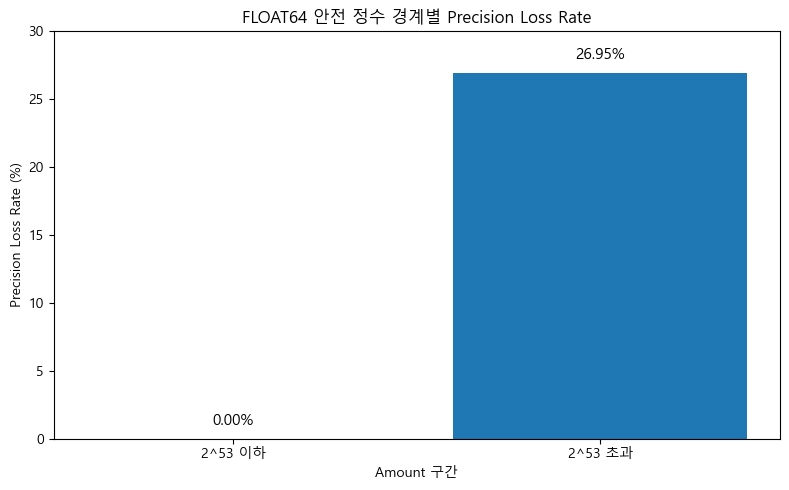

In [42]:
# 09. FLOAT64 안전 정수 경계별 Precision Loss 시각화

import matplotlib.pyplot as plt

plot_df = pd.DataFrame({
    "구간": [
        "2^53 이하",
        "2^53 초과"
    ],
    "손실률": [
        0.0,
        26.95373490
    ]
})

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    plot_df["구간"],
    plot_df["손실률"]
)

ax.set_title("FLOAT64 안전 정수 경계별 Precision Loss Rate")
ax.set_xlabel("Amount 구간")
ax.set_ylabel("Precision Loss Rate (%)")
ax.set_ylim(0, 30)

for bar, value in zip(bars, plot_df["손실률"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.7,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

## 7. FPG 설계 결론

DA-02 분석 결과 Digital Asset Amount의 Exact Preservation은 자료형 선택에 직접적인 영향을 받는 것으로 확인되었다.

BigQuery 원본 Amount와 매칭된 73,266건을 검증한 결과 Decimal 기반 처리에서는 **73,266건 전체가 정확하게 보존**되었지만,
FLOAT64 기반 처리에서는 **3,280건(4.4768%)**에서 원본 wei 손실이 발생하였다.

특히 Amount가 존재하는 Positive Amount 28,953건만을 기준으로 하면 Precision Loss Rate는 **11.3287%**였다.

FLOAT64의 연속 정수 정확 표현 경계인 `2^53`을 기준으로 구분한 결과:

- `2^53` 이하: 16,784건 중 손실 **0건**
- `2^53` 초과: 12,169건 중 손실 **3,280건(26.9537%)**

Fisher's Exact Test에서도 `2^53` 초과 여부와 Precision Loss 발생 여부 사이에 통계적으로 유의한 연관성이 확인되었다.

따라서 FPG에서 Digital Asset Amount는 일반적인 FLOAT64 숫자로 처리해서는 안 된다.

### 설계 원칙

1. Amount의 Canonical Value는 **정수 최소단위(wei)** 로 유지한다.
2. 저장·전송 과정에서 FLOAT64 변환을 허용하지 않는다.
3. 사람이 읽는 ETH Decimal 값은 표현용 값으로만 사용하며 Canonical Amount와 분리한다.
4. 외부 실행 전후 Amount를 Canonical Integer 기준으로 비교한다.
5. 원본 Amount와 실행 Amount가 일치하지 않으면 PASS 처리하지 않는다.

즉 DA-02의 핵심 설계 명제는 다음과 같다.

> **Digital Asset Amount는 표시값이 아니라 실행되는 가치이므로 Exact Preservation이 Runtime Contract 수준에서 보장되어야 한다.**

## 9. 한계

본 분석에는 다음과 같은 한계가 있다.

1. BigQuery 원본 Amount가 확인되지 않은 거래는 결측값으로 처리하여 분석에서 제외하였다.
2. 본 분석은 Ethereum native transaction의 `value`를 대상으로 하며, ERC-20 등 토큰별 Decimal Scale 구조를 직접 검증하지 않았다.
3. FLOAT64 Precision Loss를 검증한 것으로, 모든 프로그래밍 언어·DB·외부 API의 실제 직렬화 방식을 직접 재현한 것은 아니다.
4. `2^53`은 FLOAT64의 연속 정수 정확 표현 경계이며, 이를 초과한 모든 값에서 반드시 손실이 발생한다는 의미는 아니다.

따라서 본 결과는 특정 Amount 이상을 차단해야 한다는 의미가 아니라,
Digital Asset Amount 전체를 Exact-safe 자료형으로 처리해야 한다는 설계 근거로 해석한다.

## 10. 최종요약

DA-02에서는 Ethereum Amount가 데이터 처리 과정에서 원값 그대로 보존되는지를 검증하였다.

Ethereum Master Sample 73,410건 중 BigQuery 원본 Amount와 매칭된 **73,266건**을 대상으로 분석한 결과:

- Decimal 기반 Exact Preservation: **100.0000%**
- FLOAT64 Precision Loss: **3,280건**
- 전체 FLOAT64 손실률: **4.4768%**
- Positive Amount 기준 손실률: **11.3287%**
- FLOAT64 최대 절대오차: **351,232 wei**

FLOAT64의 연속 정수 정확 표현 경계인 `2^53`을 기준으로 보면:

- `2^53` 이하 16,784건: Precision Loss **0건**
- `2^53` 초과 12,169건: Precision Loss **3,280건**
- 초과 구간 손실률: **26.9537%**
- Risk Difference: **26.9537%p**

Fisher's Exact Test 결과 `2^53` 초과 여부와 Precision Loss 발생 여부 사이에는 통계적으로 유의한 연관성이 확인되었다.

반면 Decimal 기반 처리에서는 분석 대상 전체에서 원본 wei가 정확하게 보존되었다.

### 최종 FPG 설계 결론

Digital Asset Amount는 FLOAT64 기반으로 처리하지 않는다.

FPG는 Amount를 자산 최소단위의 **Canonical Integer / Exact Decimal** 형태로 유지하고,
승인된 Amount와 실제 외부 실행 Amount를 동일한 Canonical 값 기준으로 검증해야 한다.

따라서 DA-02가 제시하는 Runtime 원칙은 다음과 같다.

> **Amount는 근사값이 허용되는 일반 수치 데이터가 아니라, 승인된 가치 자체이므로 Exact Preservation을 강제해야 한다.**